# Importacion de librerías

In [1]:
# Revisar coincidencias difusas entre cadenas de texto
#!pip install geopandas plotly shapely folium fuzzywuzzy python-Levenshtein
#!pip install pandas gradio matplotlib openai tqdm

# Util cuando ciertas advertencias no son críticas y o queremos que aparezcan en la salida
import warnings
warnings.filterwarnings('ignore')

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

# Datos geoespaciales
import geopandas as gpd
from shapely.geometry import shape
import folium

# Medir distancias
!pip install geopy

# Coeficiente de correlación de Pearson
from scipy.stats import pearsonr

# Utilidades y manejo de archivos
import glob
import os

# para normalizar campos especiales, quitar espacios, pasar a minúsculas y eliminar tildes
#import unicodedata

# Autorización para que GoogleColab acceda a Drive
from google.colab import drive
drive.mount('/content/drive')

# Opciones de visualización de pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Mounted at /content/drive


# Carga de datos

Utilizaremos el **dataset 1_df_merge.csv** ya que cuenta con información que nos permitirá hacer análisis cruzados


In [2]:
df_merge = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/03. Datasets Merged/1_df_merge.csv")

# Exploración de datos


In [3]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 50 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   order_id                           102425 non-null  object 
 1   ord_customer_id                    102425 non-null  object 
 2   ord_order_status                   102425 non-null  object 
 3   ord_order_purchase_timestamp       102425 non-null  object 
 4   ord_order_approved_at              102411 non-null  object 
 5   ord_order_delivered_carrier_date   101397 non-null  object 
 6   ord_order_delivered_customer_date  100195 non-null  object 
 7   ord_order_estimated_delivery_date  102425 non-null  object 
 8   ord_purchase_to_approval_days      102411 non-null  float64
 9   ord_approval_to_carrier_days       101383 non-null  float64
 10  ord_carrier_to_customer_days       100194 non-null  float64
 11  ord_purchase_to_delivery_days      1001

Conversión de las columnas en fecha

In [4]:
# Convertir columnas de fechas al tipo datetime
fecha_columnas = [
    'ord_order_purchase_timestamp',
    'ord_order_approved_at',
    'ord_order_delivered_carrier_date',
    'ord_order_delivered_customer_date',
    'ord_order_estimated_delivery_date'
]

# Aplicar la conversión
df_merge[fecha_columnas] = df_merge[fecha_columnas].apply(pd.to_datetime, errors='coerce')

# Verificar los tipos de datos después de la conversión
df_merge[fecha_columnas].dtypes

,0
ord_order_purchase_timestamp,datetime64[ns]
ord_order_approved_at,datetime64[ns]
ord_order_delivered_carrier_date,datetime64[ns]
ord_order_delivered_customer_date,datetime64[ns]
ord_order_estimated_delivery_date,datetime64[ns]


# Selección de columnas que apliquen al análisis




In [5]:
df_cohorte = df_merge[[
    'order_id',
    'ord_customer_id',
    'ord_order_status',
    'ord_order_purchase_timestamp',
    'ord_order_approved_at',
    'ord_order_delivered_carrier_date',
    'ord_order_delivered_customer_date',
    'ord_order_estimated_delivery_date',
    'ord_order_month',
    'product_id',
    'seller_id',
    'ite_shipping_limit_date',
    'ite_price',
    'ite_freight_value',
    'ite_qty_item_id',
    'price_total',
    'freight_value_total',
    'total',
    'pro_product_category_name_english',
    'pro_peso_facturable_kg',
    'pay_pago_en_cuotas',
    'pay_multiples_medios_pago',
    'customer_id',
    'cus_customer_unique_id',
    'cus_customer_zip_code_prefix',
    'sel_seller_zip_code_prefix',
    'geo_state_cust',
    'geo_Estado_cust',
    'geo_state_sell',
    'geo_Estado_sell',
    'distancia_km',
    'estado_origen',
    'estado_destino']]

In [6]:
# Confirmamos que el DataFrame contiene las columnas seleccionadas
df_cohorte.columns


Index(['order_id', 'ord_customer_id', 'ord_order_status',
       'ord_order_purchase_timestamp', 'ord_order_approved_at',
       'ord_order_delivered_carrier_date', 'ord_order_delivered_customer_date',
       'ord_order_estimated_delivery_date', 'ord_order_month', 'product_id',
       'seller_id', 'ite_shipping_limit_date', 'ite_price',
       'ite_freight_value', 'ite_qty_item_id', 'price_total',
       'freight_value_total', 'total', 'pro_product_category_name_english',
       'pro_peso_facturable_kg', 'pay_pago_en_cuotas',
       'pay_multiples_medios_pago', 'customer_id', 'cus_customer_unique_id',
       'cus_customer_zip_code_prefix', 'sel_seller_zip_code_prefix',
       'geo_state_cust', 'geo_Estado_cust', 'geo_state_sell',
       'geo_Estado_sell', 'distancia_km', 'estado_origen', 'estado_destino'],
      dtype='object')

In [7]:
df_cohorte.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   order_id                           102425 non-null  object        
 1   ord_customer_id                    102425 non-null  object        
 2   ord_order_status                   102425 non-null  object        
 3   ord_order_purchase_timestamp       102425 non-null  datetime64[ns]
 4   ord_order_approved_at              102411 non-null  datetime64[ns]
 5   ord_order_delivered_carrier_date   101397 non-null  datetime64[ns]
 6   ord_order_delivered_customer_date  100195 non-null  datetime64[ns]
 7   ord_order_estimated_delivery_date  102425 non-null  datetime64[ns]
 8   ord_order_month                    102425 non-null  object        
 9   product_id                         102425 non-null  object        
 10  seller_id           

# OBJETIVO

Análisis de cohorte para observar la retención de clientes a lo largo del tiempo.

Adicionalmente, mediante una segmentación RFM (Recency, Frequency, Monetary), pretendemos identificar distintos grupos de clientes según la recencia de su última compra, la frecuencia de compras y el valor monetario que aportan.

Podremos, de esta forma, diseñar estrategias de marketing personalizadas para cada segmento, maximizando así la efectividad de las campañas y mejorando la satisfacción y fidelidad del cliente

En el DataFrame obervamos dos campos.

**ord_customer_id** Este campo es el número que se le da al cliente cuando realiza una compra

**cus_customer_unique_id ** Este campo es un campo único por cliente.  **sobre este campo se centrará en análisis**


In [8]:
# Confirmamos que el campos customer_unique_id no tiene valores nulos
df_merge['cus_customer_unique_id'].isnull().sum()

np.int64(0)

##  COHORTE

### Paso 1. Calcular el cohorte

In [9]:
# Extraer mes de compra
df_cohorte['mes_compra'] = df_cohorte['ord_order_purchase_timestamp'].dt.to_period('M')

# Obtener el primer mes de compra por cliente (usando ID único)
cohorte = df_cohorte.groupby('cus_customer_unique_id')['ord_order_purchase_timestamp'].min().dt.to_period('M')
df_cohorte['mes_cohorte'] = df_cohorte['cus_customer_unique_id'].map(cohorte)


In [10]:
# Convertimos periodos mensuales a fechas para calcular la diferencia
df_cohorte['cohorte_index'] = (
    (df_cohorte['mes_compra'].dt.year - df_cohorte['mes_cohorte'].dt.year) * 12 +
    (df_cohorte['mes_compra'].dt.month - df_cohorte['mes_cohorte'].dt.month)
)

# Considerar que el campo cohorte_index indica: 0 = mes de la primera compra, 1 = mes siguiente, etc.

Lo que hemos obtenido hasta aqui es el mes_cohorte (grupo de cohorte) y cohorte_index (meses desde la primera compra).  Lo que tenemos que hacer es agrupar y contar cuántos clientes únicos realizaron una compra en cada mes relativo a su cohorte

In [11]:
# Agrupar por mes de cohorte y por el índice de cohorte
cohorte_pivot = (
    df_cohorte
    .groupby(['mes_cohorte', 'cohorte_index'])['cus_customer_unique_id']
    .nunique()
    .unstack(1)
)

El código nos genera una tabla donde:

* Las filas son los meses en que los clientes hicieron su primera compra (mes_cohorte)

* Las columnas son los meses posteriores (cohorte_index)

* Las celdas indican cuántos clientes únicos compraron en cada período

In [12]:
#cohorte_pivot = cohorte_pivot.fillna('')
display(cohorte_pivot)

cohorte_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
mes_cohorte,,,,,,,,,,,,,,,,,,,,
2016-09,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,305.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,754.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1705.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2595.0,13.0,9.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,3.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2339.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,4.0,NaN,NaN,NaN
2017-05,3560.0,17.0,17.0,14.0,11.0,12.0,15.0,5.0,9.0,10.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3114.0,15.0,11.0,12.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


Procederemos a transformar la tabla cohorte_pivot de cantidad de clientes en una tabla de porcentajes de rentencion, comparando cuántos clientes regresan respecto al total de su cohorte en el mes 0

Lo que observamos es que, a medida que transcurren los meses desde la primera compra, pocos clientes interactuan con los servicios y no realizan compras.
El mes 0 tenemos el 100% de los usuarios y vemos que a medida que pasa el tiempo se ve como vamos perdiendo.

El gráfico de arriba esta en valores absolutos.  El siguiente se observará en valores relativos.

In [13]:
retencion = cohorte_pivot.divide(cohorte_pivot[0], axis=0).multiply(100).round(2)

In [14]:
retencion = retencion.fillna('')

El código divide cada fila por su valor en la columna 0 (es decir, el número de clientes originiales del mes de cohorte).  


El resultado es un porcentaje de clientes que siguen comprando con el paso del tiempo


In [ ]:
display (retencion)

cohorte_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
mes_cohorte,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,,,,,,,,,,,,,,,,,,,
2016-10,100.0,,,,,,0.33,,,0.33,,0.33,,0.33,,0.33,,0.33,0.66,0.66
2016-12,100.0,100.0,,,,,,,,,,,,,,,,,,
2017-01,100.0,0.4,0.27,0.13,0.4,0.13,0.4,0.13,0.13,,0.4,0.13,0.66,0.4,0.13,0.13,0.27,0.4,0.13,
2017-02,100.0,0.23,0.29,0.12,0.41,0.12,0.23,0.18,0.12,0.18,0.12,0.29,0.12,0.18,0.12,0.06,0.06,0.23,,
2017-03,100.0,0.5,0.35,0.39,0.35,0.15,0.15,0.31,0.35,0.08,0.39,0.12,0.23,0.12,0.15,0.23,0.08,0.15,,
2017-04,100.0,0.6,0.21,0.17,0.34,0.26,0.34,0.3,0.3,0.17,0.26,0.09,0.09,0.04,0.09,0.09,0.17,,,
2017-05,100.0,0.48,0.48,0.39,0.31,0.34,0.42,0.14,0.25,0.28,0.25,0.34,0.25,0.03,0.2,0.25,,,,
2017-06,100.0,0.48,0.35,0.39,0.26,0.39,0.39,0.22,0.13,0.22,0.32,0.35,0.16,0.13,0.19,,,,,


En el gráfico de valores relativos se confirma que la proporción de clientes que quedan luego de la primera compra es muy bajo.

Tenemos que plantear campañas de retención de clientes y los productos que compras, a pesar de tener buenos comentarios, no generan interes.  Tendríamos que proponer campañas de reactivación a través de emails o cupones de descuento.  El objetivo es reactivar a los clientes.

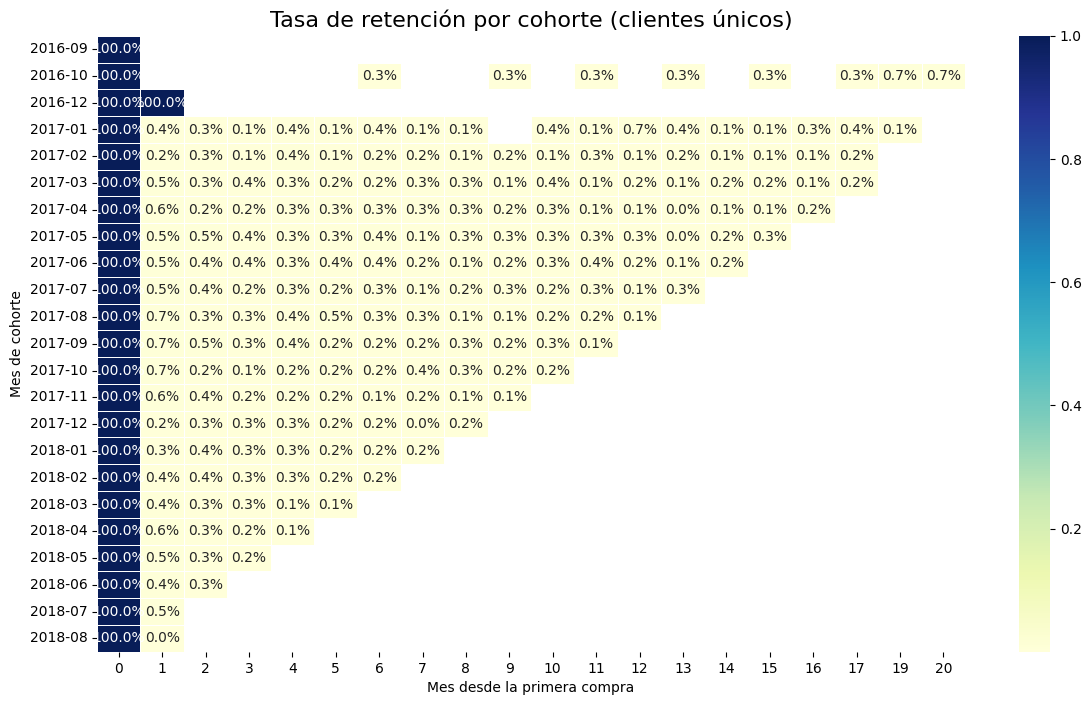

In [15]:
# valores numéricos para graficar
retencion_numeric = cohorte_pivot.divide(cohorte_pivot[0], axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(
    retencion_numeric,
    annot=True,        # Muestra los números dentro del heatmap
    fmt=".1%",         # Formato porcentaje sin decimales
    cmap="YlGnBu",     # Paleta de colores
    cbar=True,         # Barra de color a la derecha
    linewidths=0.5,    # Líneas entre celdas
    linecolor='white'  # Color de líneas
)
plt.title("Tasa de retención por cohorte (clientes únicos)", fontsize=16)
plt.ylabel("Mes de cohorte")
plt.xlabel("Mes desde la primera compra")
plt.yticks(rotation=0)
plt.show()

Observamos que menos del 1% de los clientes repite en la compra lo que nos sugiere que muchos clientes compran una sola vez.

Lo que llama la atención es que, si menos del 1% de los clientes vuelve después del primer mes, hay un problema de fidelización.

In [16]:
# Para que el gráfico que quitamos la multiplicación por 100 y el redondeo por 2
retencion = cohorte_pivot.divide(cohorte_pivot[0], axis=0)#.multiply(100).round(2)
retencion_media = retencion.mean()


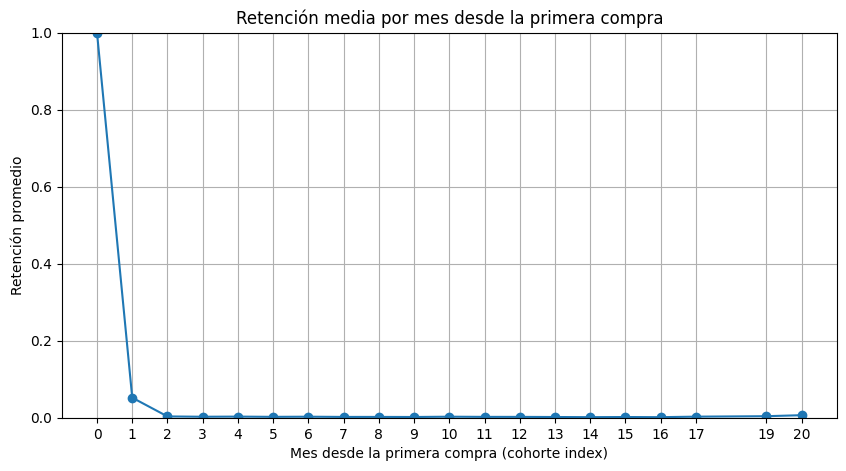

In [17]:
plt.figure(figsize=(10, 5))
retencion_media.plot(marker='o')

plt.title("Retención media por mes desde la primera compra")
plt.xlabel("Mes desde la primera compra (cohorte index)")
plt.ylabel("Retención promedio")
plt.grid(True)
plt.xticks(retencion_media.index)
plt.ylim(0, 1)
plt.show()


Confirmamos a través de este gráfico la curva decreciente de retención

### Paso 2. Cohorte por categoría

Obtención de las 5 categorías más vendidas

In [18]:
top_categorias = (
    df_merge['pro_product_category_name_english']
    .value_counts()
    .head(5)
    .index.tolist()
)



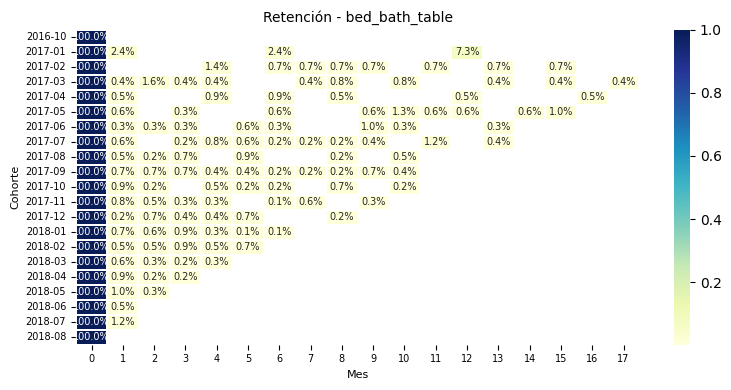

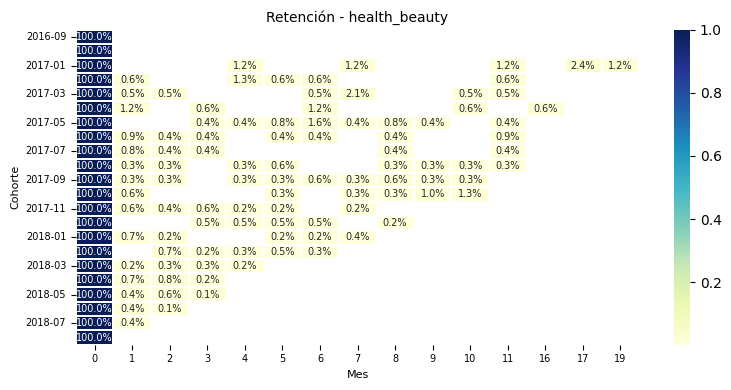

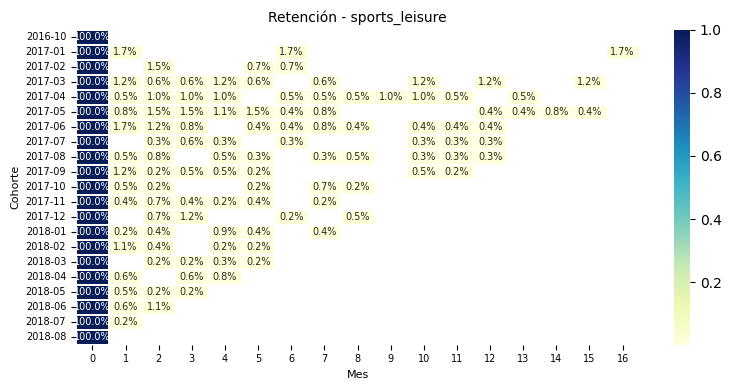

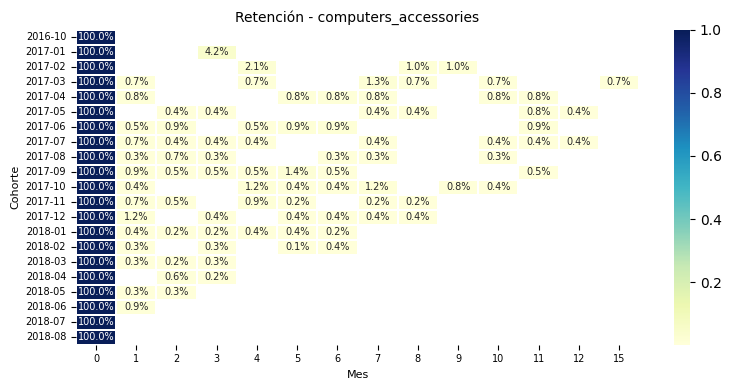

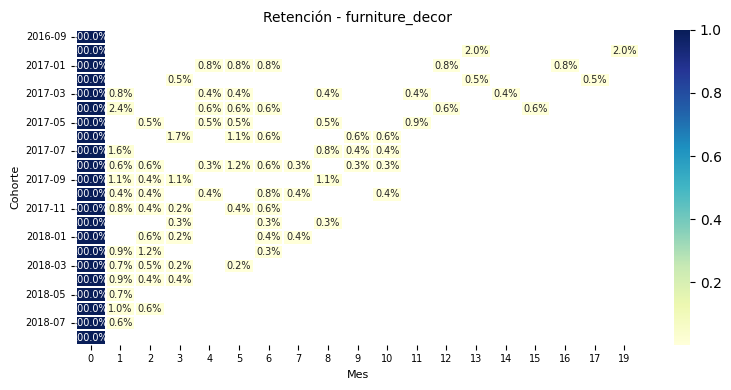

In [19]:

for categoria in top_categorias:
    df_cat = df_cohorte[df_cohorte['pro_product_category_name_english'] == categoria]

    # Crear tabla de cohortes
    cohorte_cat = (
        df_cat
        .groupby(['mes_cohorte', 'cohorte_index'])['cus_customer_unique_id']
        .nunique()
        .unstack(1)
    )

    retencion_cat = cohorte_cat.divide(cohorte_cat[0], axis=0)

    # Graficar heatmap más pequeño
    plt.figure(figsize=(8, 4))  # Tamaño reducido
    sns.heatmap(
        retencion_cat,
        annot=True,
        fmt=".1%",
        cmap="YlGnBu",
        linewidths=0.3,
        linecolor='white',
        annot_kws={"size": 7}  # Tamaño de texto más pequeño
    )
    plt.title(f"Retención - {categoria}", fontsize=10)
    plt.ylabel("Cohorte", fontsize=8)
    plt.xlabel("Mes", fontsize=8)
    plt.xticks(fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()



Confirmamos que las categorías gráficadas estánd entre de las 10 con más vendidas (en cantidad) y que generan más ingresos.

In [20]:
# Agrupar por la columna correcta y calcular métricas
ventas_por_categoria = (
    df_merge.groupby('pro_product_category_name_english')
    .agg(
        total_items_vendidos=('ite_qty_item_id', 'sum'),
        ingresos_totales=('ite_price', 'sum')
    )
    .sort_values(by='total_items_vendidos', ascending=False)
    .head(10)
)



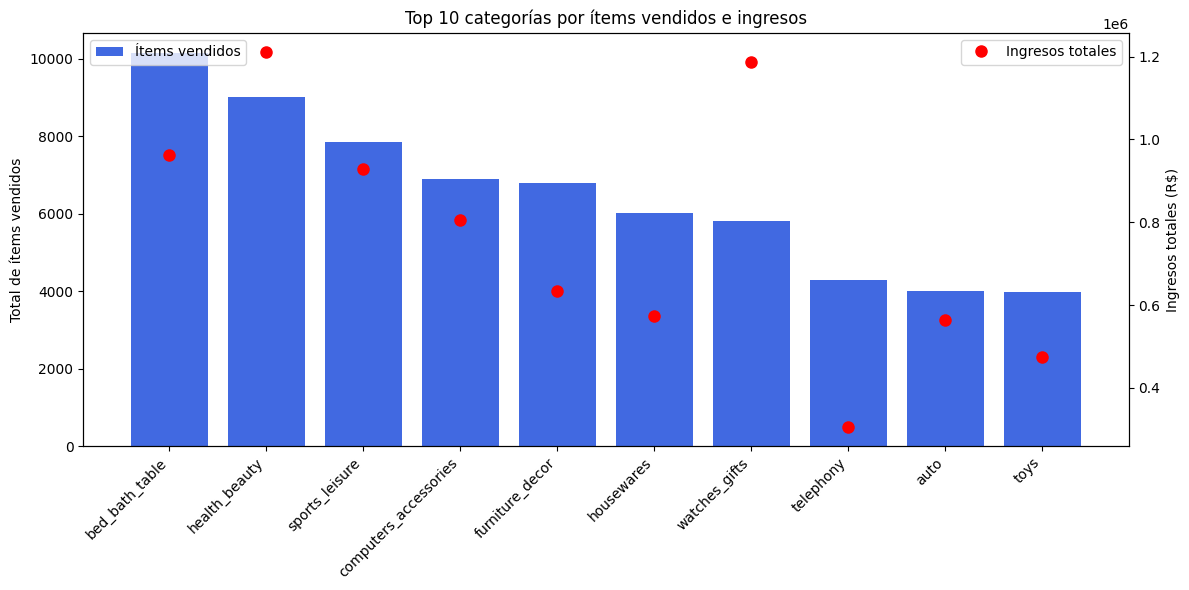

In [21]:

# Agrupar por categoría y calcular ítems vendidos y suma de ingresos
agrupado = df_merge.groupby('pro_product_category_name_english').agg({
    'order_id': 'count',
    'ite_price': 'sum'
}).rename(columns={'order_id': 'items_vendidos', 'ite_price': 'ingresos'})

# Tomar el top 10 por cantidad de ítems vendidos
top_categorias = agrupado.sort_values(by='items_vendidos', ascending=False).head(10)

# Definir variables para graficar
categorias = top_categorias.index.tolist()
items_vendidos = top_categorias['items_vendidos'].tolist()
ingresos = top_categorias['ingresos'].tolist()

# Crear gráfico ajustado con colores solicitados
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras en azul más fuerte
ax1.bar(categorias, items_vendidos, color='royalblue', label='Ítems vendidos')

# Puntos rojos sin línea
ax2 = ax1.twinx()
ax2.plot(categorias, ingresos, 'o', color='red', label='Ingresos totales', markersize=8)

# Estética
ax1.set_ylabel('Total de ítems vendidos')
ax2.set_ylabel('Ingresos totales (R$)')
ax1.set_title('Top 10 categorías por ítems vendidos e ingresos')
ax1.set_xticklabels(categorias, rotation=45, ha='right')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Segmentación RFM (Recencia, Frecuencia, M-valor monetario)

Con esta segmentación lo que buscamos es definir campañas de marketing, de comunicación, a que tipo de cliente queremos impactar.  Segmentamos a los clientes en base a tres metricas.

Lo que vamos a calcular es lo siguiente:

| Métrica | Comentarios|
|---------|------------|
| Recency | Días desde la última compra hasta una fecha de referencia.
| | Un valor bajo de recencia indica que ha tenido una compra reciente.
| | Ese valor indicaría que el cliente tiene una relación de mayor fidelidad.
| Frequency | Número de órdenes únicas hechas por el cliente
| Monetary | Suma total del gasto del cliente (Precio + costo de envío)

### Paso 1. Creación de DataFrame base

In [22]:
# vemos los valores minimos y máximos de la fecha de compra
df_merge['ord_order_purchase_timestamp'].agg({'min','max'})

,ord_order_purchase_timestamp
min,2016-09-04 21:15:19
max,2018-09-03 09:06:57


In [23]:
# Crear df_rfm base con columnas relevantes
df_rfm = df_merge[[
    'cus_customer_unique_id',
    'ord_order_purchase_timestamp',
    'order_id',
    'total'  # Usamos el total de la compra
]].copy()

In [24]:
# Establecemos una fecha de referencia.  Para el ejercicio tomaremos la fecha de compra más reciente.
fecha_referencia = df_rfm['ord_order_purchase_timestamp'].max()

print(fecha_referencia)

2018-09-03 09:06:57


In [25]:
# Agrupación por cliente único

# A la fecha de referencia le restamos la fecha más reciente x.max(). Esto nos devuelve los días desde la última compra
# order_id: nunique nos devuelve cuántos IDs de orden distintos tiene ese cliente (cuántas veces ha comprado)


rfm = df_rfm.groupby('cus_customer_unique_id').agg({
    'ord_order_purchase_timestamp': lambda x: (fecha_referencia - x.max()).days,  # Recency
    'order_id': 'nunique',                                                        # Frequency
    'total': 'sum'                                                                # Monetary
}).reset_index()



In [26]:
# Renombramos las columnas
rfm.columns = ['id_unico_cliente', 'Recency', 'Frequency', 'Monetary']

 ### Paso 2. Exploración y visualización


Revisamos clientes por recencia.  Cuantos días han pasado desde la última compra (por cliente).


Lo que observamos en la columna Recency es la cantidad de días desde la compra más reciente con respecto a la última compra.


In [27]:
rfm.sort_values(by='Recency').head(10)

,id_unico_cliente,Recency,Frequency,Monetary
95083,ff22e30958c13ffe219db7d711e8f564,0,2,332.92
1538,0421e7a23f21e5d54efed456aedbc513,4,1,119.42
13741,24ac2b4327e25baf39f2119e4228976a,4,1,93.75
34576,5c58de6fb80e93396e2f35642666b693,4,1,510.96
12704,21dbe8eabd00b34492a939c540e2b1a7,4,1,14.29
67518,b4dcade04bc548b7e3b0243c801f8c26,4,1,106.95
68312,b701bebbdf478f5500348f03aff62121,4,1,33.23
4676,0c6d7218d5f3fa14514fd29865269993,4,1,178.25
47802,7febafa06d9d8f232a900a2937f04338,4,1,61.29
45599,7a22d14aa3c3599238509ddca4b93b01,4,1,73.10


Revisamos la frecuencia de compra de cada cliente.


La columna Frequency nos indica cuantas veces ha comprado el cliente.  A mayor cantidad de veces un cliente más leal

In [28]:
rfm.sort_values(by='Frequency', ascending=False).head(10)


,id_unico_cliente,Recency,Frequency,Monetary
52597,8d50f5eadf50201ccdcedfb9e2ac8455,13,16,902.04
23302,3e43e6105506432c953e165fb2acf44c,187,9,1172.67
10281,1b6c7548a2a1f9037c1fd3ddfed95f33,200,7,959.01
75560,ca77025e7201e3b30c44b472ff346268,93,7,1122.72
37532,6469f99c1f9dfae7733b25662e7f1782,67,7,758.83
89814,f0e310a6839dce9de1638e0fe5ab282a,151,6,540.69
37320,63cfc61cee11cbe306bff5857d00bfe4,97,6,826.32
82305,dc813062e0fc23409cd255f7f53c7074,11,6,1033.62
26849,47c1a3033b8b77b3ab6e109eb4d5fdf3,221,6,944.21
7124,12f5d6e1cbf93dafd9dcc19095df0b3d,605,6,110.72


Revisamos el aporte monetario por cliente

In [29]:
rfm.sort_values(by='Monetary', ascending=False).head(10)

,id_unico_cliente,Recency,Frequency,Monetary
3799,0a0a92112bd4c708ca5fde585afaa872,338,1,13664.08
81388,da122df9eeddfedc1dc1f5349a1a690c,519,2,7571.63
44139,763c8b1c9c68a0229c42c9fc6f662b93,49,1,7274.88
82230,dc4802a71eae9be1dd28f5d788ceb526,567,1,6929.31
26015,459bef486812aa25204be022145caa62,39,1,6922.21
95131,ff4159b92c40ebe40454e3e6a7c35ed6,466,1,6726.66
23947,4007669dec559734d6f53e029e360987,282,1,6081.54
34820,5d0a2980b292d049061542014e8960bf,52,1,4809.44
89056,eebb5dda148d3893cdaf5b5ca3040ccb,502,1,4764.34
27242,48e1ac109decbb87765a3eade6854098,72,1,4681.78


rfm.describe() confirmamos los valores obtenidos en las visualizaciones

El valor máximo en Frequency son 16 (un cliente ha comprado 16 veces) y el valor más alto han sido R$13664.08

In [30]:
rfm.describe()


,Recency,Frequency,Monetary
count,95420.000000,95420.000000,95420.000000
mean,242.600377,1.034018,166.040172
std,153.160320,0.211234,228.320333
min,0.000000,1.000000,9.590000
25%,118.000000,1.000000,63.100000
50%,223.000000,1.000000,107.940000
75%,352.000000,1.000000,183.220000
max,728.000000,16.000000,13664.080000


Lo que estamos buscando es asignar niveles para cada combinacion de Receny, Frecuency y Montary.  Lo que buscamos es tener niveles (alto, medio o bajo) que nos permita identificar aquellos clientes que son:

* de alto valor
* de medio valor
* de bajo valor y que, por lo tanto, necesitan más atención



### Paso 3. Segmentación por cuartiles

Lo que buscamos es dividir cada métrica RFM en 3 grupos (terciles), asignando una puntuación del 1 al 3

Recency: 3 = más reciente, 1 = más antiguo

Frequency: 3 = más frecuente, 1 = menos frecuente

Monetary: 3 = más valor económico, 1 = menos valor económico

In [31]:
# Recency → cuanto menor, mejor (más reciente)
rfm['R_tercil'] = pd.qcut(rfm['Recency'], 3, labels=[3, 2, 1])

# Frequency y Monetary → cuanto mayor, mejor
rfm['F_tercil'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1, 2, 3])
rfm['M_tercil'] = pd.qcut(rfm['Monetary'].rank(method='first'), 3, labels=[1, 2, 3])


In [32]:
rfm['RFM_Score'] = (
    rfm['R_tercil'].astype(str) +
    rfm['F_tercil'].astype(str) +
    rfm['M_tercil'].astype(str)
)



In [33]:
def clasificar_cliente(score):
    if score == '333':
        return 'Clientes estrella'
    elif score[0] == '1':                     # Recency bajo = compra antigua
        return 'Clientes inactivos'
    elif score[1] == '3' or score[2] == '3':  # Frecuencia o gasto alto
        return 'Clientes valiosos'
    else:
        return 'Clientes promedio'

rfm['Segmento'] = rfm['RFM_Score'].apply(clasificar_cliente)


In [34]:
rfm['Segmento'].value_counts()


,count
Segmento,
Clientes inactivos,31658
Clientes valiosos,31205
Clientes promedio,28611
Clientes estrella,3946


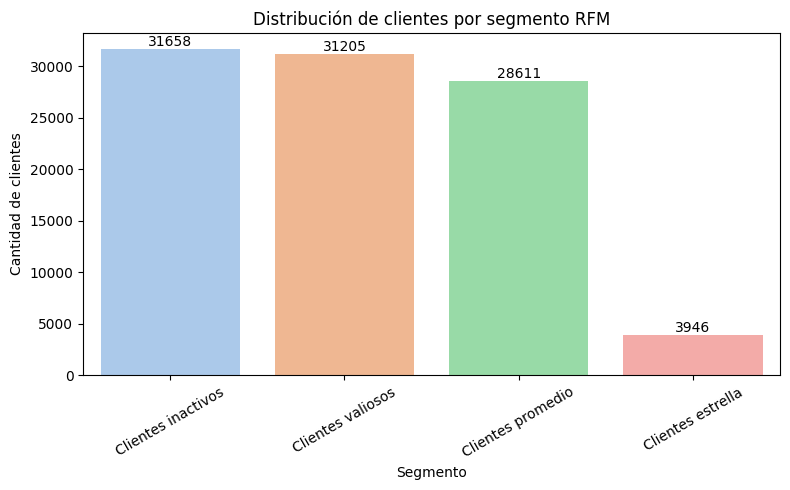

In [35]:
segmentos = rfm['Segmento'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=segmentos.index, y=segmentos.values, palette='pastel')

# Añadir etiquetas encima de cada barra
for i, valor in enumerate(segmentos.values):
    ax.text(i, valor + 1, str(valor), ha='center', va='bottom', fontsize=10)

plt.title("Distribución de clientes por segmento RFM")
plt.xlabel("Segmento")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Con esta segmentación podemos identificar
1. Clientes estrella (RFM_Score = '333')
  * Recency alta → hace poco que compraron

  * Frequency alta → compran a menudo

  * Monetary alta → gastan mucho

Son clientes valiosos a los que deberíamos fidelizar otorgandoles un trato especial o promociones exclusivas


2. Clientes valiosos (F= 3 o M = 3, R < 3)
  * Compran mucho o con frecuencia
  * No han comprado recientemente

Estos son clientes que no han comprando recientemente y que se necesita reactivar a traves de recordatorios, emails u ofertas especiales.


3. Clientes inactivos (R = 3)
  * Hace mucho que no compran
  * Pueden haber comprado mucho o poco antes

Estos son clientes en riesgo de abandono.  Considerar estrategias de reactivación o encuentas para entender por qué dejaron de comprar.

4. Clientes promedio (todos los demás)
  * Tienen puntuaciones medias en Recency, Frequency y Monetary
  * No destacan, pero tienen potencial

Son clientes estables o nuevos sin patrón claro.  Se puede intentar trabajar con contenido personalizado o recomendaciones.


### Paso 4. Ventas totales por segmento

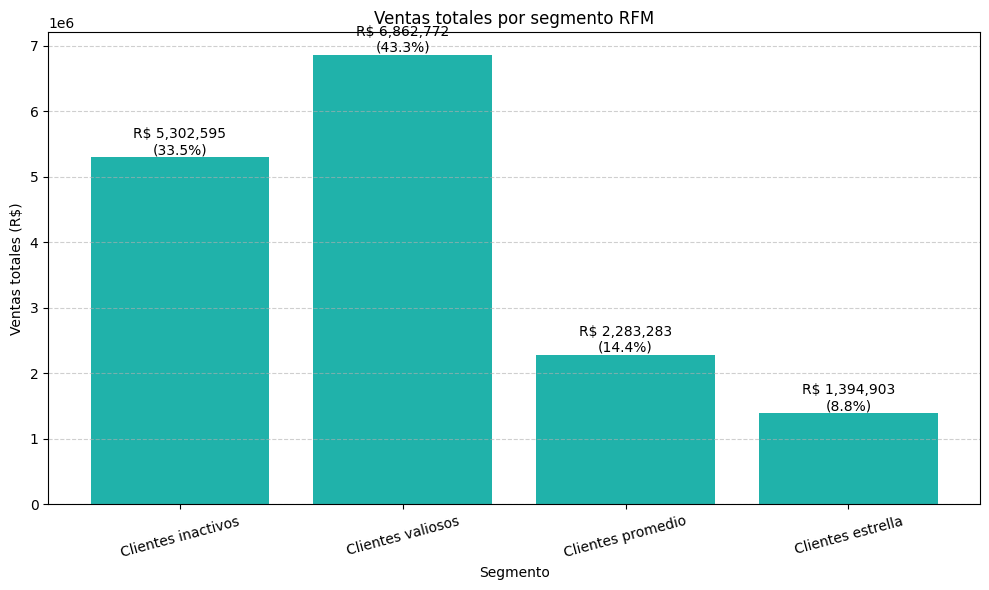

In [36]:
# --- Agregar ventas y agrupar por segmento ---
rfm['Total_ventas'] = rfm['Monetary']

resumen_segmento = rfm.groupby('Segmento').agg({
    'id_unico_cliente': 'count',
    'Total_ventas': 'sum'
}).reset_index().rename(columns={
    'id_unico_cliente': 'Cantidad_clientes',
    'Total_ventas': 'Ventas_totales_R$'
})

# Ordenar según lógica deseada
orden_segmentos = ['Clientes inactivos', 'Clientes valiosos', 'Clientes promedio', 'Clientes estrella']
resumen_segmento['Segmento'] = pd.Categorical(resumen_segmento['Segmento'], categories=orden_segmentos, ordered=True)
resumen_segmento = resumen_segmento.sort_values('Segmento')

# Calcular porcentaje
total_ventas = resumen_segmento['Ventas_totales_R$'].sum()
resumen_segmento['Porcentaje'] = (resumen_segmento['Ventas_totales_R$'] / total_ventas) * 100

# --- Gráfico ---
plt.figure(figsize=(10, 6))
bars = plt.bar(resumen_segmento['Segmento'], resumen_segmento['Ventas_totales_R$'], color='lightseagreen')

# Etiquetas: total + porcentaje
for bar, total, pct in zip(bars, resumen_segmento['Ventas_totales_R$'], resumen_segmento['Porcentaje']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'R$ {total:,.0f}\n({pct:.1f}%)',
             ha='center', va='bottom')

plt.title('Ventas totales por segmento RFM')
plt.ylabel('Ventas totales (R$)')
plt.xlabel('Segmento')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



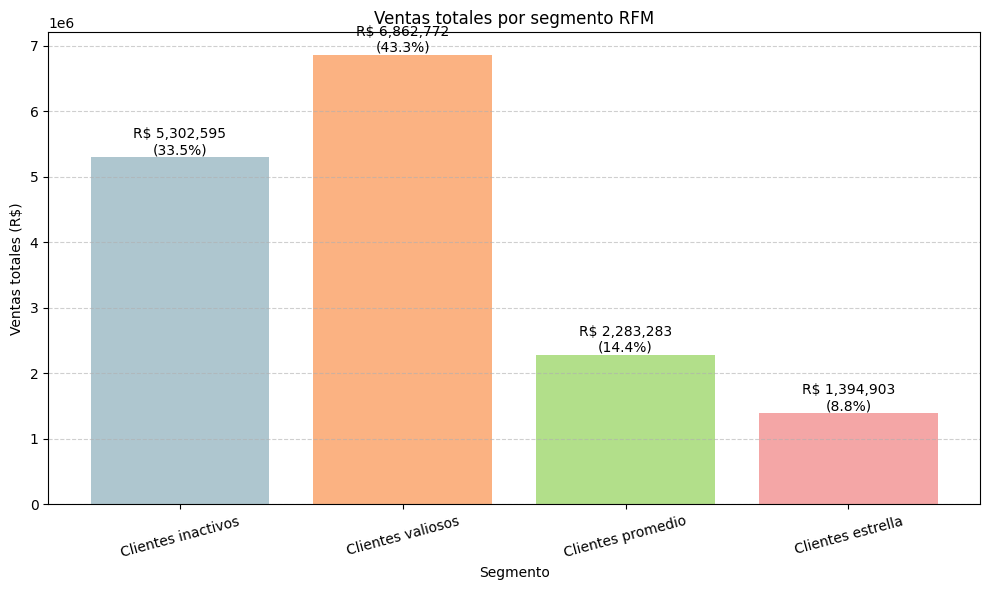

In [37]:
# Simular datos de resumen_segmento con orden específico
resumen_segmento = pd.DataFrame({
    'Segmento': ['Clientes inactivos', 'Clientes valiosos', 'Clientes promedio', 'Clientes estrella'],
    'Ventas_totales_R$': [5302595, 6862772, 2283283, 1394903],
    'Porcentaje': [33.5, 43.3, 14.4, 8.8]
})

# Paleta de colores pastel como en el primer gráfico
palette = ['#aec6cf', '#fbb282', '#b2df8a', '#f4a6a6']

# Crear gráfico con colores personalizados
plt.figure(figsize=(10, 6))
bars = plt.bar(resumen_segmento['Segmento'], resumen_segmento['Ventas_totales_R$'], color=palette)

# Etiquetas: total + porcentaje
for bar, total, pct in zip(bars, resumen_segmento['Ventas_totales_R$'], resumen_segmento['Porcentaje']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'R$ {total:,.0f}\n({pct:.1f}%)',
             ha='center', va='bottom')

plt.title('Ventas totales por segmento RFM')
plt.ylabel('Ventas totales (R$)')
plt.xlabel('Segmento')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
